# Compact Modeling of the UBC Crossing

This notebook turns the `ebeam_crossing4` UBC/SiEPIC-style crossing into a compact broadband model using BEAMZ. We import the PDK cell, place a modal source and DFT monitors directly from the port metadata, run a 3D simulation, and extract the four-port S-parameters needed for circuit-level reuse.


**Author:** Quentin Wach
**Published:** 2026-05-02
**Updated:** 2026-05-02
**Tags:** Simulation, Compact Models, PDK


## Setup and Physical Parameters

The workflow follows the standalone `tiny_beamz_crossing.py` example, but is reorganized for notebook use. The only external assumption is that the matching `gdsfactory` + UBC PDK environment is installed and active so `gdsf.prepare_component(...)` can resolve `ebeam_crossing4`.


In [1]:
import numpy as np
import matplotlib.pyplot as plt

from beamz import LIGHT_SPEED, ModeSource, Monitor, PML, PortSpec, Simulation, dxdt, µm
from beamz.design.io import gdsf
from beamz.devices._placement import mirror_lock_plane_pair_regions
from beamz.devices.sources.signals import gaussian_band_pulse

COMPONENT_NAME = "ebeam_crossing4"
LAYER = (1, 0)

WL0 = 1550.0e-9
WL_MIN = 1530.0e-9
WL_MAX = 1570.0e-9
NUM_FREQS = 16
PPW = 8

N_CORE = 3.47
N_CLAD = 1.44
CORE_T = 0.22 * µm
CLAD_BELOW = 0.50 * µm
CLAD_ABOVE = 0.50 * µm

PML_XY = 1.0 * µm
PML_Z = 1.0 * µm
XY_MARGIN = 0.50 * µm
Z_PADDING = 0.50 * µm
EXTENSION = XY_MARGIN + PML_XY
PORT_OVERLAP = 0.0 * µm
PORT_MARGIN = 0.50 * µm
MONITOR_Z_SPAN = CORE_T + 2.0 * PORT_MARGIN
SOURCE_PORT_OFFSET = 0.10 * µm
DISTANCE_SOURCE_TO_MONITORS = 0.40 * µm
OUTPUT_MONITOR_OFFSET = 0.05 * µm

RUN_AFTER_SOURCES_UOC = 90.0
DECAY_RATIO = 1e-4
LOOKBACK_RECORDS = 20
PML_FORMULATION = "sigma"


## Port Geometry Helpers

BEAMZ projects fields onto guided modes on monitor planes. The helpers below convert imported PDK port metadata into source and monitor line segments, then provide a lightweight overview plot so the placement is visible before the expensive run.


In [2]:
def incoming_wave(direction: str) -> str:
    return "minus" if str(direction).startswith("+") else "plus"


def outgoing_wave(direction: str) -> str:
    return incoming_wave(gdsf.outward_direction(direction))


def move_along(center: tuple[float, float], direction: str, distance: float):
    x, y = center
    return {
        "+x": (x + distance, y),
        "-x": (x - distance, y),
        "+y": (x, y + distance),
        "-y": (x, y - distance),
    }[str(direction)]


def port_plane(port: dict, *, span: float, z_span: float, z_center: float, offset: float = 0.0):
    cx, cy = move_along(port["center"], port["direction"], offset)
    z0 = float(z_center) - 0.5 * float(z_span)
    z1 = float(z_center) + 0.5 * float(z_span)
    if str(port["direction"]).endswith("x"):
        return (cx, cy - 0.5 * float(span), z0), (cx, cy + 0.5 * float(span), z1)
    return (cx - 0.5 * float(span), cy, z0), (cx + 0.5 * float(span), cy, z1)


def line_center(line):
    a, b = line
    return tuple(0.5 * (float(a[i]) + float(b[i])) for i in range(len(a)))


def port_mode_geometry(port: dict) -> tuple[float, float, float]:
    width = float(port["width"])
    span = max(width + 2.0 * PORT_MARGIN, width + 0.1 * µm)
    return span, float(MONITOR_Z_SPAN), float(port["z_center"])


def plot_simulation_overview(eps_grid, *, width, height, depth, z_focus, source_plane, monitor_planes, world_origin=(0.0, 0.0, 0.0)):
    eps_grid = np.asarray(eps_grid, dtype=float)
    if eps_grid.ndim == 3:
        z_idx = int(np.clip(round((z_focus / max(depth, 1e-30)) * (eps_grid.shape[0] - 1)), 0, eps_grid.shape[0] - 1))
        eps_view = eps_grid[z_idx]
    else:
        eps_view = eps_grid

    fig, ax = plt.subplots(figsize=(6.4, 5.4), dpi=140)
    im = ax.imshow(
        eps_view,
        origin="lower",
        extent=[
            world_origin[0] / µm,
            (world_origin[0] + width) / µm,
            world_origin[1] / µm,
            (world_origin[1] + height) / µm,
        ],
        cmap="viridis",
        aspect="equal",
    )
    plt.colorbar(im, ax=ax, label="Permittivity", fraction=0.046, pad=0.04)

    def _plot_plane(line, label, color):
        (x0, y0, _), (x1, y1, _) = line
        ax.plot(
            [(x0 + world_origin[0]) / µm, (x1 + world_origin[0]) / µm],
            [(y0 + world_origin[1]) / µm, (y1 + world_origin[1]) / µm],
            color=color,
            lw=2.0,
            label=label,
        )

    _plot_plane(source_plane, "source", "white")
    for name, plane in monitor_planes.items():
        _plot_plane(plane, name, "tab:red")

    ax.set_xlabel("x (µm)")
    ax.set_ylabel("y (µm)")
    ax.set_title("Crossing layout with modal planes")
    ax.legend(loc="upper right", fontsize=8, frameon=True)
    fig.tight_layout()
    plt.show()


def plot_sparameters_db(wl_um: np.ndarray, s_matrix: dict):
    fig, ax = plt.subplots(figsize=(6.6, 4.3), dpi=140)
    for (out_port, in_port), values in sorted(s_matrix.items()):
        arr = np.asarray(values, dtype=np.complex128)
        ax.plot(wl_um, 20.0 * np.log10(np.maximum(np.abs(arr), 1e-12)), lw=2.0, label=f"S[{out_port},{in_port}]")
    ax.set_xlabel("Wavelength (µm)")
    ax.set_ylabel("Magnitude (dB)")
    ax.set_title("UBC crossing S-parameters")
    ax.grid(alpha=0.3)
    ax.legend(loc="best", frameon=False)
    fig.tight_layout()
    plt.show()


def wave_dominance_db(a_plus: np.ndarray, a_minus: np.ndarray, selector: str, mask: np.ndarray) -> float:
    sel = np.asarray(a_plus if selector == "plus" else a_minus, dtype=np.complex128)
    opp = np.asarray(a_minus if selector == "plus" else a_plus, dtype=np.complex128)
    valid = np.asarray(mask, dtype=bool)
    if not np.any(valid):
        return float("nan")
    p_sel = float(np.mean(np.abs(sel[valid]) ** 2))
    p_opp = float(np.mean(np.abs(opp[valid]) ** 2))
    return 10.0 * np.log10(max(p_sel, 1e-18) / max(p_opp, 1e-18))


## Import the UBC Crossing and Place the Modal Planes

The crossing is imported from the PDK, extruded to 3D, padded for absorbing boundaries, and extended so the guided mode is sampled on uniform straight sections rather than in the immediate scattering region.


● Auto-selecting 3D meshing for 3D design

Output()

● 3D raster timing: setup=0.07s, structures=2.08s, pml=0.00s, total=2.19s

● 3D raster kernels: fast_enabled=True, fast_rect=2, fast_poly=1, fallback=0

● Created 3D mesh: 225 × 225 × 139 cells

● Raster cache saved: 1dfafe5f4fee6d0bae90cba2c2d02f10ff7bd5fa916b0d5c39fa380759d28291.npz | save=1.80s

● Rasterize wall-time: 2.20s | total=4.00s

Component: ubcpdk.gds.ebeam_crossing4
Grid: (139, 225, 225), dx = 0.0558 µm, dt = 107.423 as
Sweep: 1.5300–1.5700 µm with 16 points


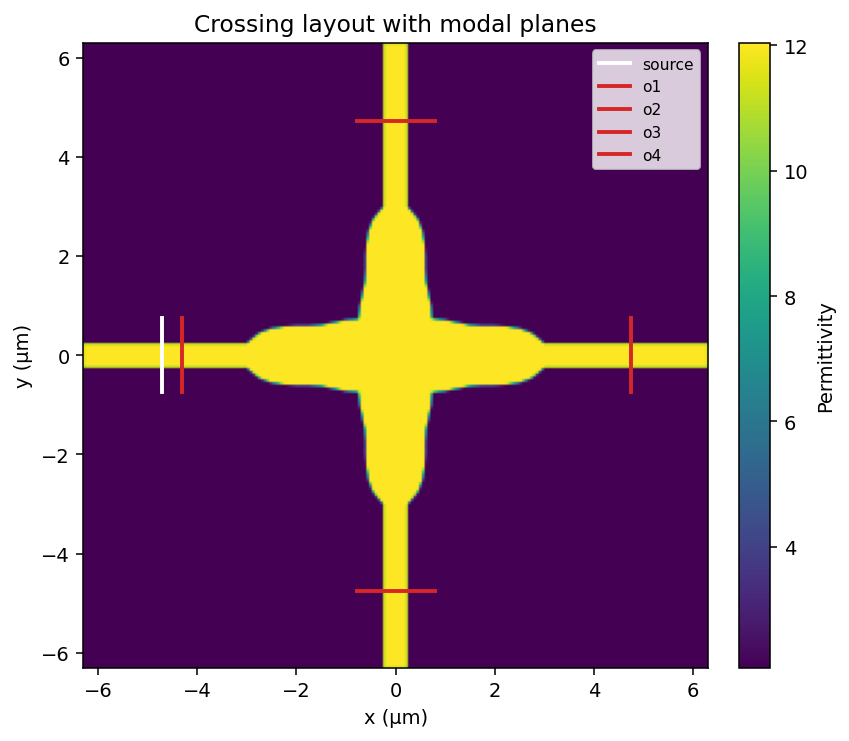

In [3]:
try:
    prepared = gdsf.prepare_component(
        COMPONENT_NAME,
        layer=LAYER,
        n_core=N_CORE,
        n_clad=N_CLAD,
        core_thickness=CORE_T,
        clad_below=CLAD_BELOW,
        clad_above=CLAD_ABOVE,
        xy_padding=EXTENSION,
        z_padding=Z_PADDING + PML_Z,
        extension=EXTENSION,
        port_overlap=PORT_OVERLAP,
    )
except ValueError as exc:
    raise RuntimeError(
        "Could not resolve the UBC crossing. Activate the matching gdsfactory/UBC PDK environment before running this notebook."
    ) from exc

component_label = prepared["component_label"]
design = prepared["design"]
ports = prepared["ports"]
world_origin = tuple(float(v) for v in prepared.get("world_origin", (0.0, 0.0, 0.0)))

source_port = "o1"
output_ports = ["o2", "o3", "o4"]

dx, dt = dxdt(WL0, n_max=N_CORE, dims=3, safety_factor=0.999, points_per_wavelength=PPW)
grid = design.rasterize(resolution=dx)
freqs = np.linspace(LIGHT_SPEED / WL_MAX, LIGHT_SPEED / WL_MIN, NUM_FREQS, dtype=np.float32)
wl_um = LIGHT_SPEED / freqs / µm

src = ports[source_port]
source_direction = src["direction"]
source_span, z_span, source_z_center = port_mode_geometry(src)
source_plane = port_plane(
    src,
    span=source_span,
    z_span=z_span,
    z_center=source_z_center,
    offset=SOURCE_PORT_OFFSET,
)
source_center = line_center(source_plane)

monitor_offsets = {source_port: SOURCE_PORT_OFFSET + DISTANCE_SOURCE_TO_MONITORS}
monitor_planes = {
    source_port: port_plane(
        src,
        span=source_span,
        z_span=z_span,
        z_center=source_z_center,
        offset=monitor_offsets[source_port],
    )
}

for port_name in output_ports:
    port = ports[port_name]
    span, monitor_z_span, z_center = port_mode_geometry(port)
    monitor_offsets[port_name] = OUTPUT_MONITOR_OFFSET
    monitor_planes[port_name] = port_plane(
        port,
        span=span,
        z_span=monitor_z_span,
        z_center=z_center,
        offset=monitor_offsets[port_name],
    )

o2_region, o4_region = mirror_lock_plane_pair_regions(
    start_a=monitor_planes["o2"][0],
    end_a=monitor_planes["o2"][1],
    start_b=monitor_planes["o4"][0],
    end_b=monitor_planes["o4"][1],
    plane_normal="y",
    size_a=None,
    size_b=None,
    dx=dx,
    dy=dx,
    dz=dx,
    shape=tuple(np.asarray(grid.permittivity).shape),
)
monitor_planes["o2"] = (o2_region.start, o2_region.end)
monitor_planes["o4"] = (o4_region.start, o4_region.end)

print(f"Component: {component_label}")
print(f"Grid: {grid.permittivity.shape}, dx = {dx / µm:.4f} µm, dt = {dt * 1e18:.3f} as")
print(f"Sweep: {wl_um.min():.4f}–{wl_um.max():.4f} µm with {NUM_FREQS} points")

plot_simulation_overview(
    np.asarray(grid.permittivity, dtype=float),
    width=design.width,
    height=design.height,
    depth=design.depth,
    z_focus=source_z_center,
    source_plane=source_plane,
    monitor_planes=monitor_planes,
    world_origin=world_origin,
)


## Run the 3D Simulation and Extract the Broadband S-Matrix

We use one TE mode source on `o1`, DFT monitors on all ports, and a reference monitor colocated with the source plane so the incident field can be normalized cleanly. The final call to `get_S_matrix_modal_dft(...)` gives the compact four-port response directly from the in-simulation frequency-domain accumulators.


## Interactive 3D Design Preview

Before running the time-domain solve, render the imported crossing in the notebook. `design.show()` loads the BEAMZ web widget so the full 3D extruded geometry can be inspected interactively.


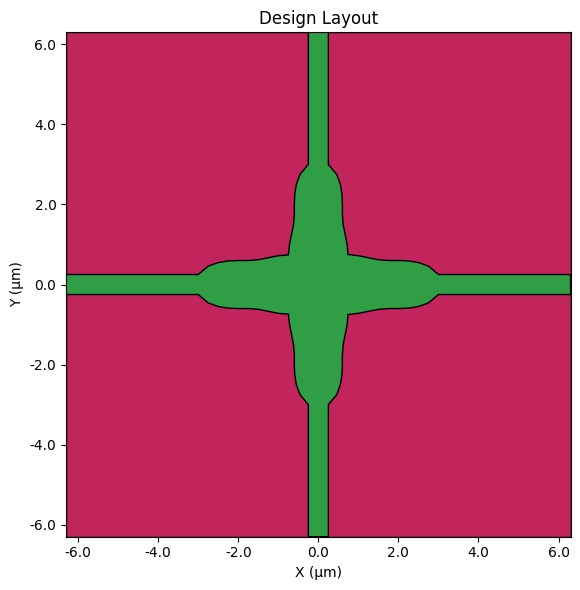

(<Figure size 600x600 with 1 Axes>,
 <Axes: title={'center': 'Design Layout'}, xlabel='X (µm)', ylabel='Y (µm)'>)

In [4]:
design.show()


/Users/quentinwach/Code/beamz-1/beamz/simulation/core.py:405: RuntimeWarning: PML material varies along the absorber normal on edges ['left', 'right', 'top', 'bottom']. For lower reflection, extrude the boundary material profile through the PML or keep geometry clear of the absorber.
  new_data = pml.create_pml_regions(


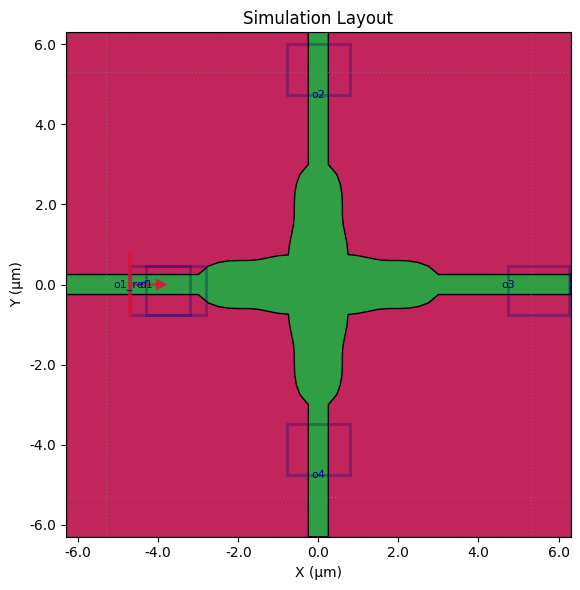

● Progress: 66% (8704/13090 steps)
Executed 8704 time steps
o2 outgoing-wave dominance: 7.23 dB
o3 outgoing-wave dominance: 29.63 dB
o4 outgoing-wave dominance: 7.44 dB
S[o1,o1] @ 1.5511 µm = -42.21 dB
S[o2,o1] @ 1.5511 µm = -50.59 dB
S[o3,o1] @ 1.5511 µm = -1.18 dB
S[o4,o1] @ 1.5511 µm = -50.48 dB


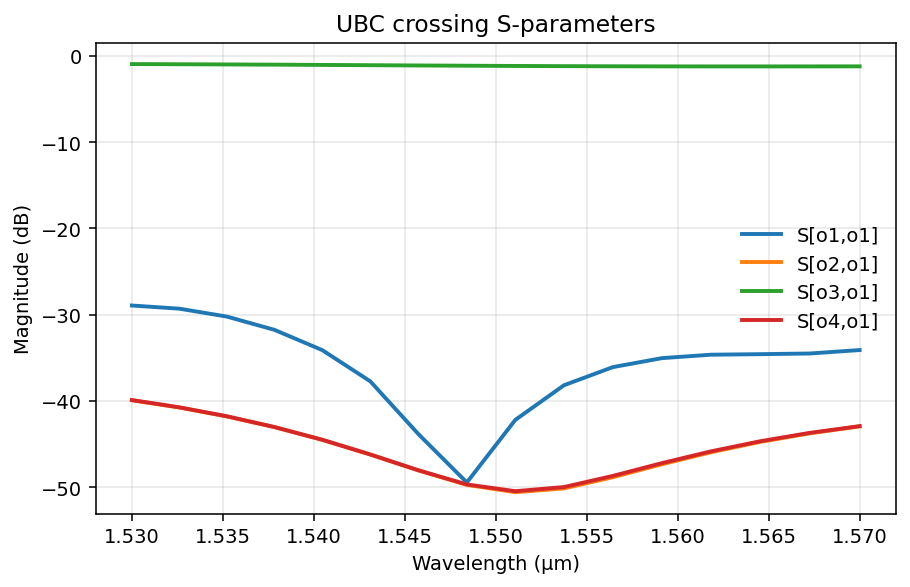

In [5]:
runtime_output_distance_um = 0.0
for port_name in output_ports:
    c_out = line_center(monitor_planes[port_name])
    runtime_output_distance_um = max(
        runtime_output_distance_um,
        float(np.hypot(c_out[0] - source_center[0], c_out[1] - source_center[1])) / µm,
    )

pulse = gaussian_band_pulse(
    freqs,
    carrier_frequency=LIGHT_SPEED / WL0,
    dt=dt,
    run_after_sources_uoc=RUN_AFTER_SOURCES_UOC,
    max_output_distance_um=runtime_output_distance_um,
)

source = ModeSource(
    grid=grid,
    center=source_center,
    width=source_span,
    height=z_span,
    wavelength=WL0,
    pol="te",
    signal=pulse.signal,
    direction=source_direction,
)
source.initialize(grid.permittivity, dx)

monitor_cfg = dict(
    record_fields=False,
    dft_enabled=True,
    dft_frequencies=freqs,
    dft_components=("Ex", "Ey", "Ez", "Hx", "Hy", "Hz"),
    dft_window="none",
    dft_record_every_step=True,
)

monitors = [
    Monitor(start=monitor_planes[p][0], end=monitor_planes[p][1], name=p, **monitor_cfg)
    for p in (source_port, *output_ports)
]
reference_monitor = Monitor(start=source_plane[0], end=source_plane[1], name="o1_ref", **monitor_cfg)

sim = Simulation(
    design=design,
    sources=[source],
    monitors=[*monitors, reference_monitor],
    boundaries=[
        PML(edges=["left", "right", "top", "bottom"], thickness=PML_XY, formulation=PML_FORMULATION),
        PML(edges=["front", "back"], thickness=PML_Z, formulation=PML_FORMULATION),
    ],
    time=pulse.time,
    resolution=dx,
)

sim.show()

executed_steps = sim.run_compiled_until_decay(
    monitors,
    min_time_s=pulse.source_end_time + pulse.tail_time,
    lookback_records=LOOKBACK_RECORDS,
    decay_ratio=DECAY_RATIO,
    progress=True,
)
print(f"Executed {executed_steps} time steps")

port_specs = [
    PortSpec(
        name="o1",
        monitor_name="o1",
        reference_monitor="o1_ref",
        direction=gdsf.positive_axis_direction(source_direction),
        polarization="te",
        mode_index=0,
        incident_wave=incoming_wave(source_direction),
        scattered_wave=outgoing_wave(source_direction),
    )
]

for port_name in output_ports:
    direction = ports[port_name]["direction"]
    port_specs.append(
        PortSpec(
            name=port_name,
            monitor_name=port_name,
            direction=gdsf.positive_axis_direction(direction),
            polarization="te",
            mode_index=0,
            incident_wave=incoming_wave(direction),
            scattered_wave=outgoing_wave(direction),
        )
    )

result = sim.get_S_matrix_modal_dft(
    source_port="o1",
    ports=port_specs,
    output_ports=["o1", *output_ports],
    frequencies=freqs,
    as_sax=False,
    return_diagnostics=True,
    min_incident_db=-45.0,
)

s_matrix = {
    (port_name, "o1"): np.asarray(result["s_matrix"][(port_name, "o1")], dtype=np.complex128)
    for port_name in ["o1", *output_ports]
}

valid = np.asarray(result["diagnostics"]["valid_mask"], dtype=bool)
for port_name in output_ports:
    waves = result["diagnostics"]["waves"][port_name]
    dominance = wave_dominance_db(
        waves["a_plus"],
        waves["a_minus"],
        outgoing_wave(ports[port_name]["direction"]),
        valid,
    )
    print(f"{port_name} outgoing-wave dominance: {dominance:.2f} dB")

i0 = int(np.argmin(np.abs(wl_um - WL0 / µm)))
for port_name in ["o1", *output_ports]:
    mag = np.abs(s_matrix[(port_name, "o1")][i0])
    print(f"S[{port_name},o1] @ {wl_um[i0]:.4f} µm = {20.0 * np.log10(max(mag, 1e-12)):.2f} dB")

plot_sparameters_db(wl_um, s_matrix)


## Package the Result as a Lightweight Compact Model

At this point the crossing is reduced to wavelength-dependent complex S-parameters. The small helper below stores the broadband response and evaluates it at arbitrary wavelengths by separately interpolating the real and imaginary parts of each transfer coefficient.


In [6]:
compact_model = {
    "component": component_label,
    "wavelength_um": np.asarray(wl_um, dtype=float),
    "ports": ["o1", "o2", "o3", "o4"],
    "s_parameters": {f"{out_port},{in_port}": values for (out_port, in_port), values in s_matrix.items()},
    "metadata": {
        "center_wavelength_um": WL0 / µm,
        "resolution_um": dx / µm,
        "component_name": COMPONENT_NAME,
        "layer": LAYER,
    },
}


def evaluate_crossing(wavelength_um):
    wl_query = np.atleast_1d(np.asarray(wavelength_um, dtype=float))
    wl_grid = compact_model["wavelength_um"]
    evaluated = {}
    for key, values in compact_model["s_parameters"].items():
        values = np.asarray(values, dtype=np.complex128)
        real = np.interp(wl_query, wl_grid, values.real)
        imag = np.interp(wl_query, wl_grid, values.imag)
        evaluated[key] = real + 1j * imag
    return evaluated


sample = evaluate_crossing([1.53, 1.55, 1.57])
for key, values in sorted(sample.items()):
    print(key, np.round(20.0 * np.log10(np.maximum(np.abs(values), 1e-12)), 2))


o1,o1 [-28.95 -28.95 -28.95]
o2,o1 [-39.94 -39.94 -39.94]
o3,o1 [-0.96 -0.96 -0.96]
o4,o1 [-39.91 -39.91 -39.91]


This notebook gives you the same essential outcome as the standalone script, but in a form that is easier to inspect, rerun, and adapt. From here you can export `compact_model` to your preferred circuit simulator format, densify the wavelength sweep, or repeat the same workflow for other imported PDK components.
